In [1]:
# IROS optimisation by hand - SCOX-1

from singleCAM_IROS._pipeline_support import _handle_dirpaths

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import shift2pos, shift2angle, angle2shift, equatorial2shift
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask, count, decode
from bloodmoon.optim import model_sky as bm_sky

import darksun as ds
from darksun.data import DataLoader, CatalogueLoader

from fract_shift2 import model_shadowgram


def extract_catalogue_angular_coords(
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    """
    s, txs, tys = [], [], []
    for sourceID in np.unique(catalogue.DLdata['ID']):
        source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)]
        #sx, sy = equatorial2shift(sdl, camera, source['RA'][0], source['DEC'][0])
        sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
        thetax, thetay = map(lambda x: shift2angle(wfm, x), (sx, sy))
        s.append(sourceID)
        txs.append(thetax)
        tys.append(thetay)

    df = pd.DataFrame(
        {'ID': s, 'THETAX': txs, 'THETAY': tys}
    )
    return df

def model_sky(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    fluence: float,
    vignetting: bool = True,
    psfy: bool = True,
    bkg: NDArray | None = None,
) -> NDArray:
    """
    Generate a model of the reconstructed sky image for a point source.
    """
    detector = model_shadowgram(
        camera, shift_x, shift_y, vignetting=vignetting, psfy=psfy,
    ) * fluence
    if bkg is not None:
        detector += bkg
    return decode(camera, detector)


#skyfield = "IROSDummy"
#mask_FITS = "wfm_mask_NTHT_20250725.fits"
##mask_FITS = "wfm_mask_summer2021.fits"
#data_FITS = "scox1_2-50keV_mask_050_1040x17_1ks_infdet_opaquemask_newpathinmask"

skyfield = "GalacticCentre"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

mask_path, simul_data, _ = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)

source_ID = 'gx5-1'

#from var import detector_solid_angle
#
#rng = np.random.default_rng()
#
#omega = detector_solid_angle(wfm)
#cxb_detector = omega / omega.sum() * rng.poisson(17400, (wfm.shape_detector)).sum() * wfm.bulk


from pathlib import Path

def savefig_to(
    figpath: str | Path,
    name: str,
    frmt: str = 'png',
) -> str | Path | None:
    """
    Creates the filepath to save a Figure with the chosen format,
    and checks if the file already exists. If the file exists,
    `None` is returned to avoid the file overwriting. 
    """
    def is_img(filepath: Path) -> bool:
        """Checks if a file has been already saved."""
        return filepath.is_file()
    
    filepath = f'{figpath}/{name}.{frmt}'
    if not is_img(Path(filepath)):
        return filepath
    return None

save_to = '/home/edoardo/Desktop/PSF_test'

Selected 123497 ph out of 2566482 ph.

GX5-1 angular coords: (np.float64(3.8119659117577713), np.float64(-3.52589041835914))



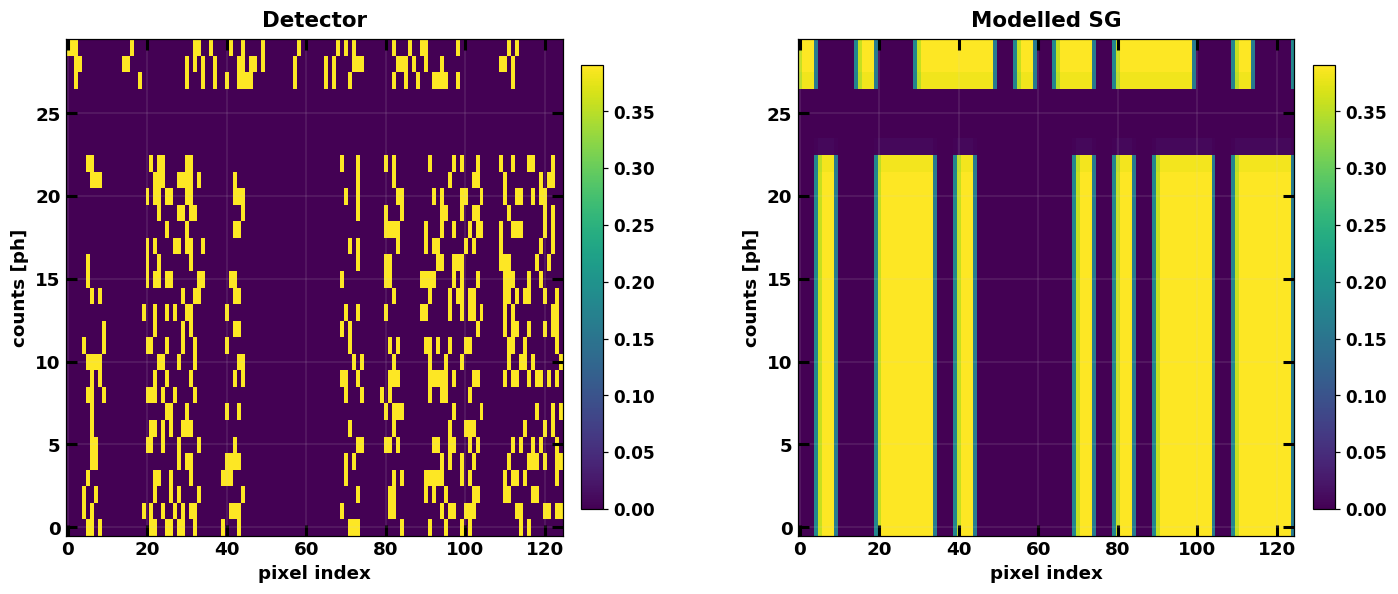

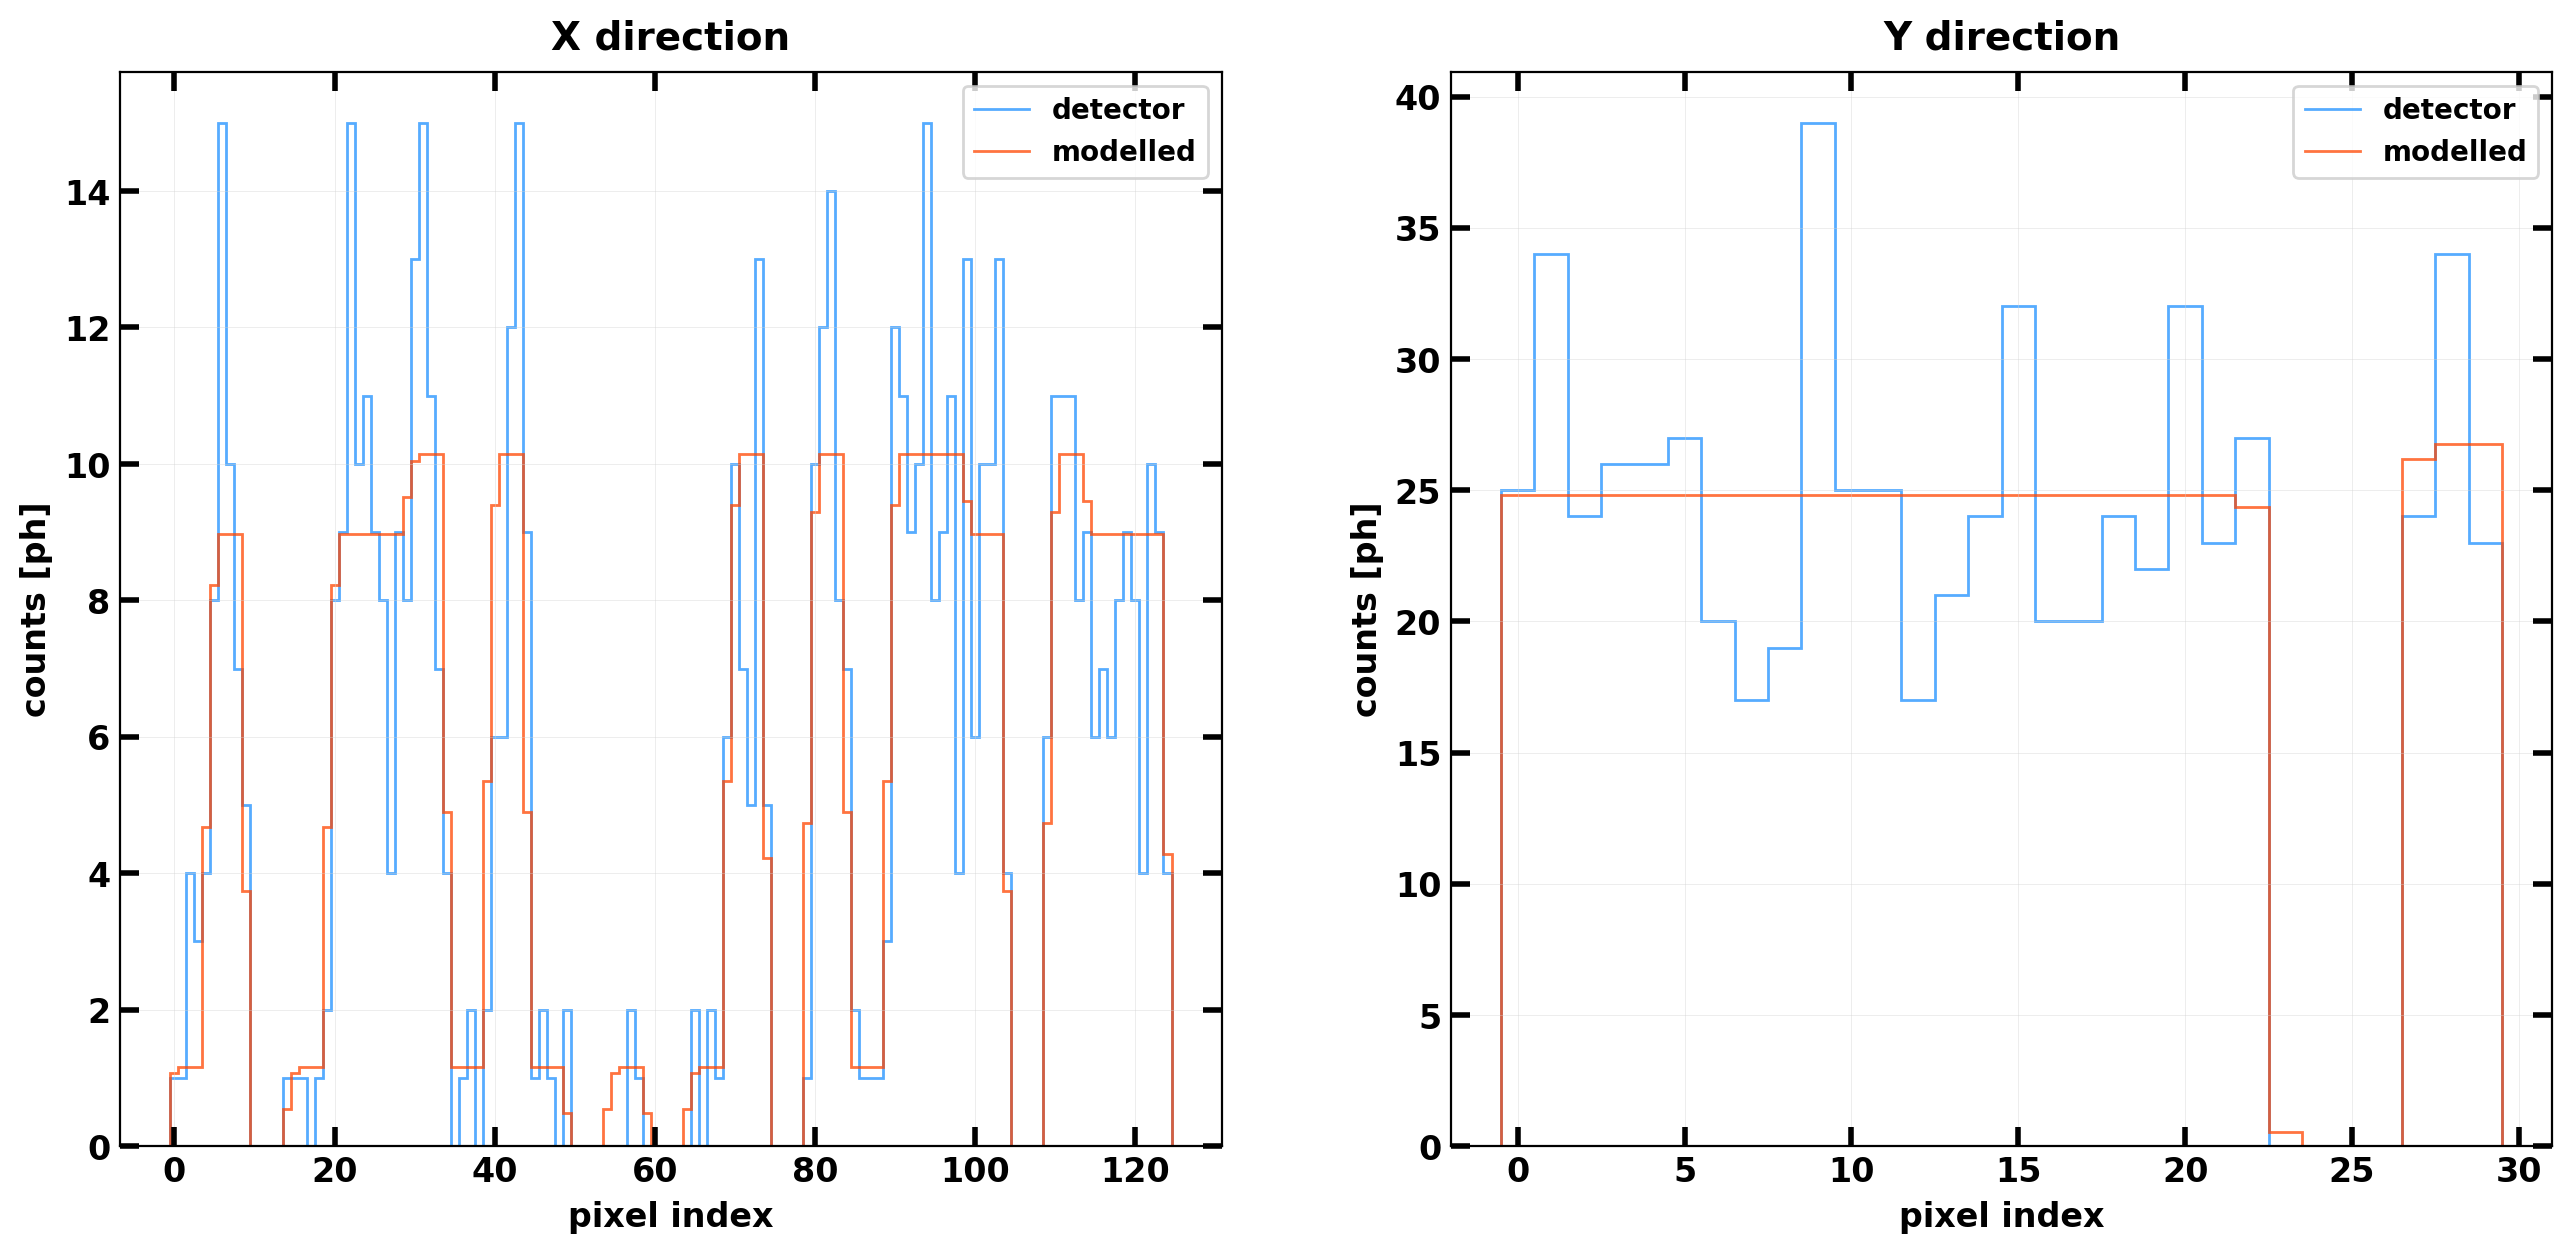

In [2]:
from astropy.io.fits.fitsrec import FITS_rec

def select_source_photons(
    coords: CoordEquatorial | tuple[CoordEquatorial, ...],
    data: FITS_rec,
) -> FITS_rec:
    """
    Selects photon events relative to the input source RA/Dec coords.
    """
    mask = np.ones(len(data), dtype=bool)
    for c in ((coords,) if isinstance(coords, CoordEquatorial) else coords):
        mask &= (
            (np.isclose(data['RA'], c.ra) & np.isclose(data['DEC'], c.dec))
        )
    selected = data[mask]
    print(f'Selected {len(selected)} ph out of {len(data)} ph.')
    return selected


def collapse_view(arr: NDArray) -> tuple[NDArray, NDArray]:
    """
    Collapses input 2D array by adding the elements along
    one axis, for both the (x, y) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along the y axis
            - collapsed array along the x axis
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along y has length `m`, while the collapsed
          array along x has length `n`.
    """
    return np.sum(arr, axis=0), np.sum(arr, axis=1)


def extract_section(
    arr: NDArray,
    rows: slice,
    cols: slice,
) -> NDArray:
    """Returns an array view of the input array."""
    return arr[rows, cols]


sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])

source_rec = catalogueA.DLdata[(catalogueA.DLdata['ID'] == source_ID)]
coords = CoordEquatorial(source_rec['RA'][0], source_rec['DEC'][0])
source_photons = select_source_photons(coords=coords, data=sdlA.DLdata)

shiftx, shifty = equatorial2shift(sdlA, wfm, coords.ra, coords.dec)
thetax, thetay = map(lambda x: shift2angle(wfm, x), (shiftx, shifty))
print(f'\n{source_ID.upper()} angular coords: {thetax, thetay}\n')

detector, _ = count(wfm, source_photons)
true_sky = decode(wfm, detector)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.0 * np.max(true_sky[i - 5 * UPY : i + 5 * UPY, j - 2 * UPX : j + 2 * UPX])

source_sg = model_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY) * fluence


slicerows, slicecols = slice(170, 200), slice(1165, 1290)
ext_det, ext_sg = map(
    lambda x: extract_section(x, slicerows, slicecols),
    (detector, source_sg),
)
det_x, det_y = collapse_view(ext_det)
sg_x, sg_y = collapse_view(ext_sg) 

ASPECT = ext_det.shape[1] / ext_det.shape[0] # (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)
dmap_img_det = ds.map4image(
    img=ext_det,
    title='Detector',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'vmax': ext_sg.max(),
        'aspect': ASPECT,
    }
)
dmap_img_sg = ds.map4image(
    img=ext_sg,
    title='Modelled SG',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'aspect': ASPECT,
    }
)
ds.image_plot((dmap_img_det, dmap_img_sg), ncols=2)

dmap_collapsed_x = ds.map4plot(
    arrs=(det_x, sg_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_x, sg_x)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(det_y, sg_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_y, sg_y)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
ds.plot((dmap_collapsed_x, dmap_collapsed_y), ncols=2)

Selected 123997 ph out of 2495985 ph.

GX5-1 angular coords: (np.float64(-3.5258904183590936), np.float64(-3.8119659117577744))



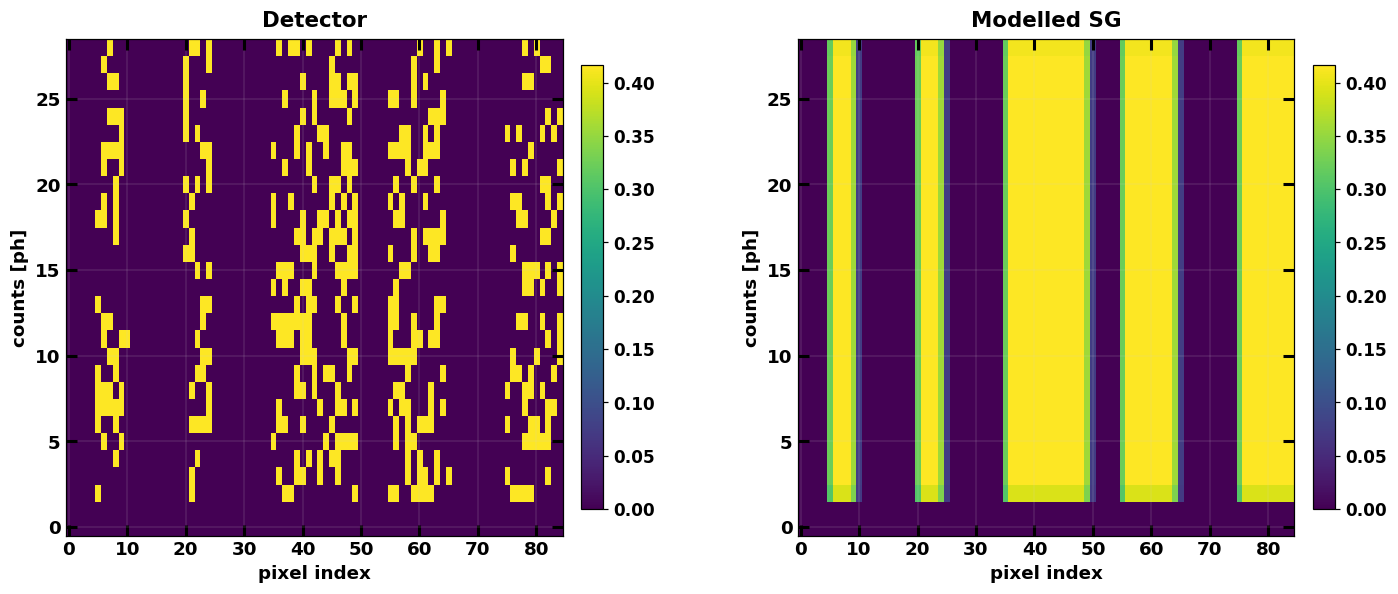

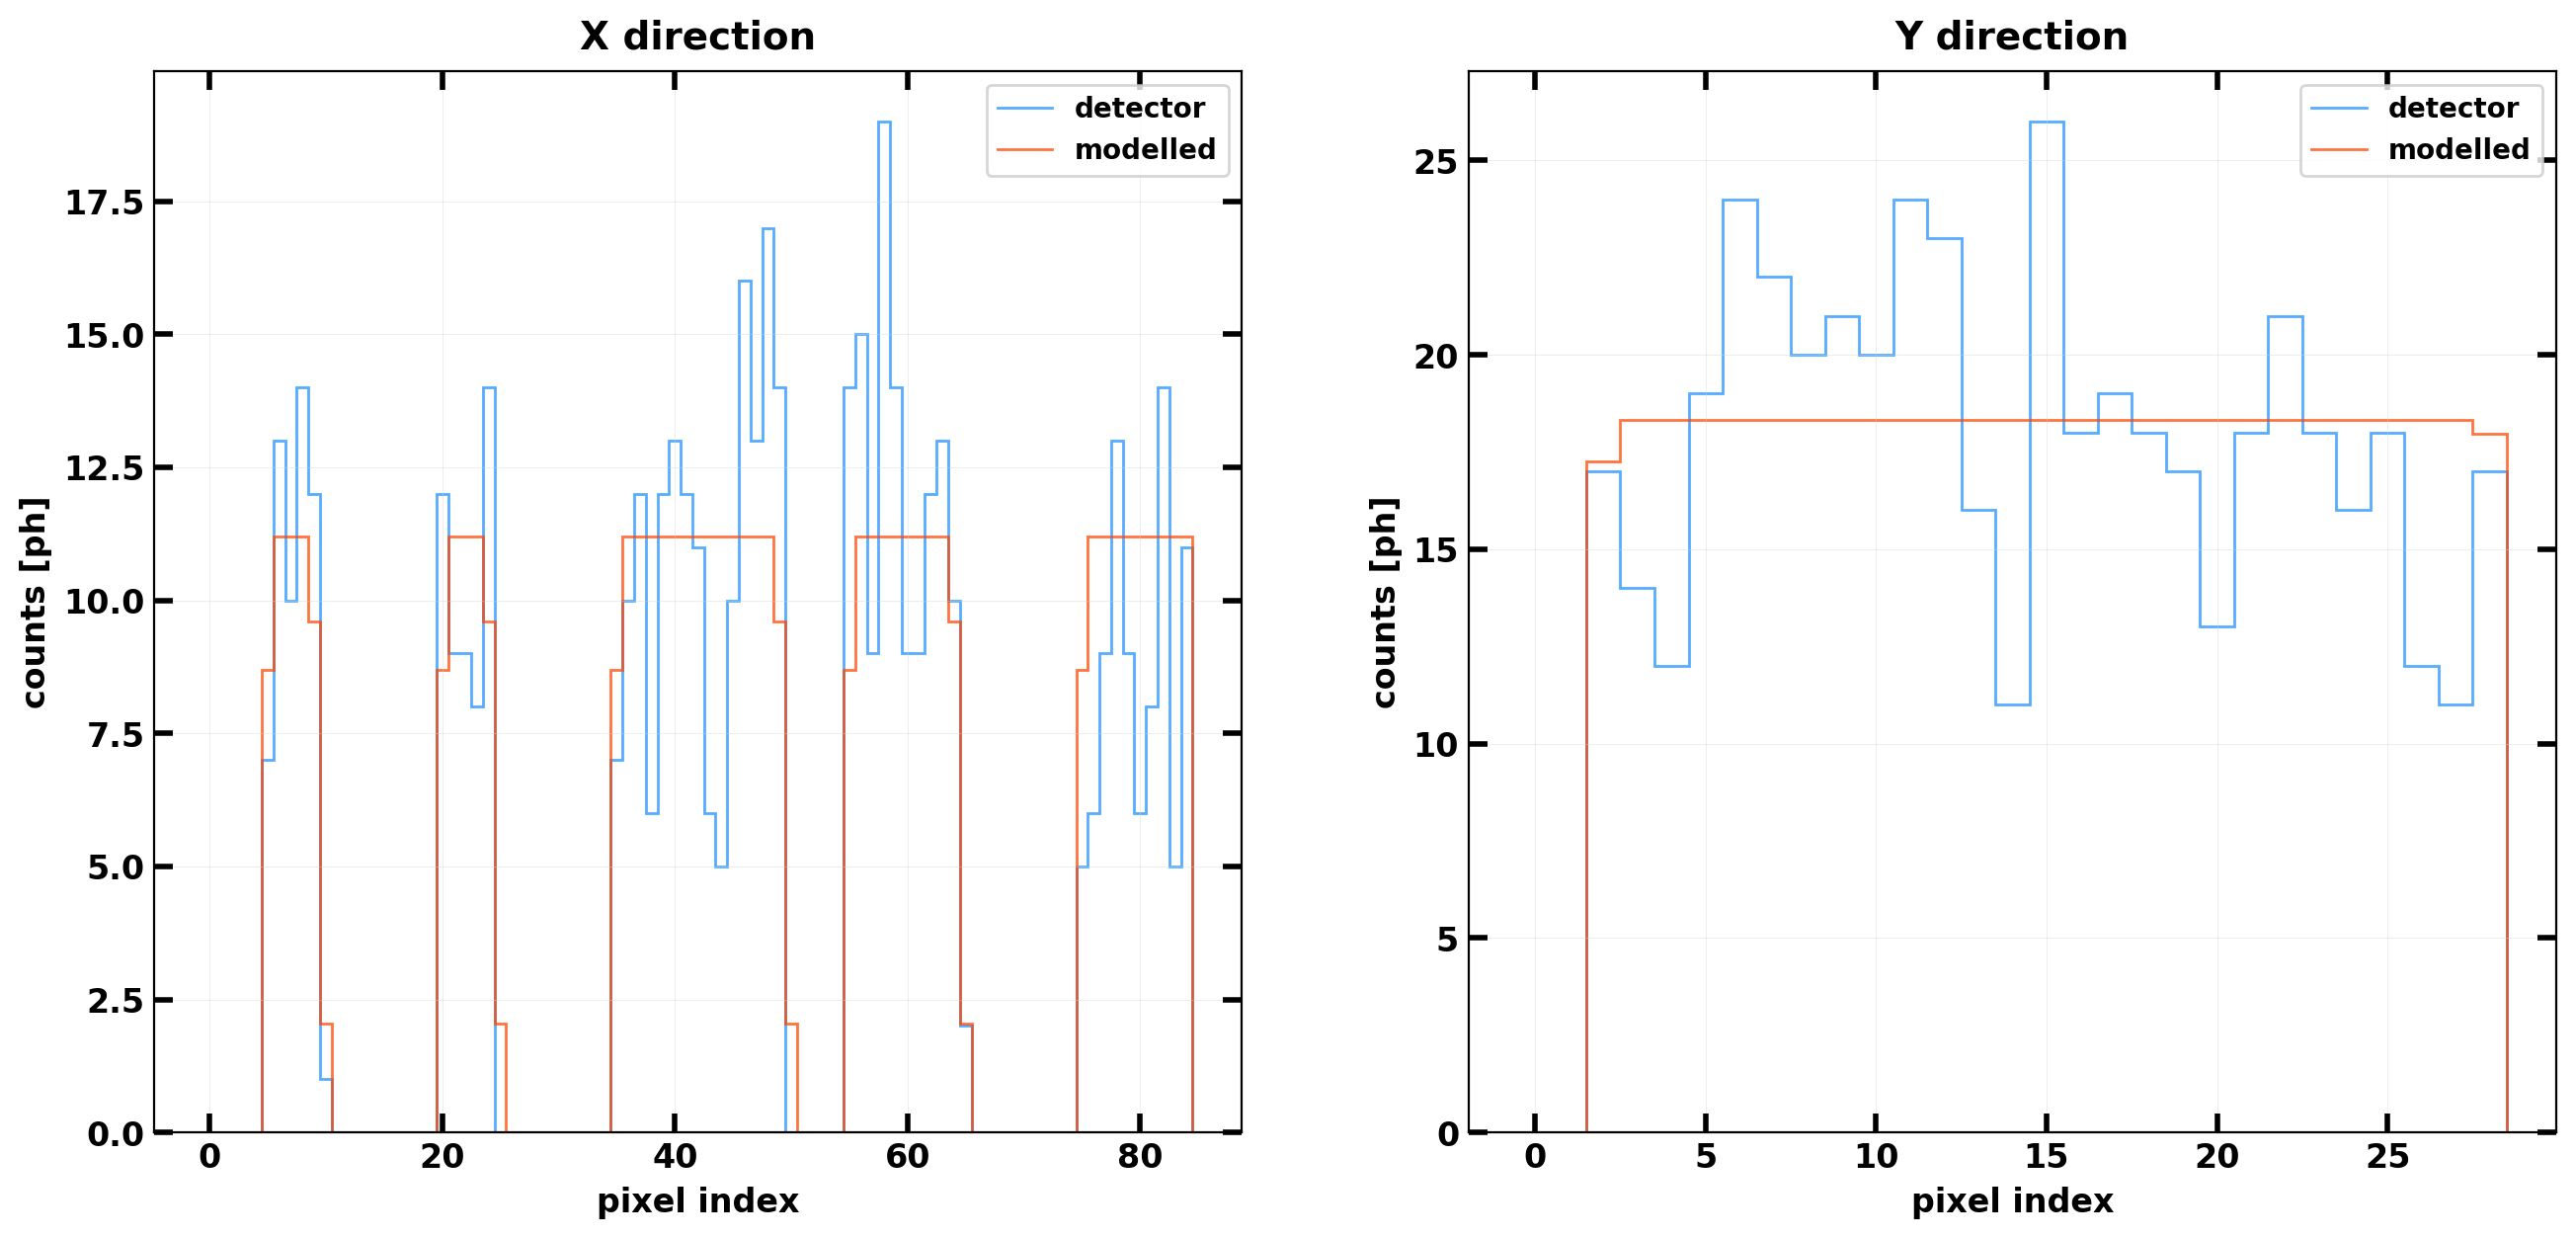

In [3]:
sdlB = ds.get_data(filepaths[cam_b][dataset])
catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

source_rec = catalogueB.DLdata[(catalogueB.DLdata['ID'] == source_ID)]
coords = CoordEquatorial(source_rec['RA'][0], source_rec['DEC'][0])
source_photons = select_source_photons(coords=coords, data=sdlB.DLdata)

shiftx, shifty = equatorial2shift(sdlB, wfm, coords.ra, coords.dec)
thetax, thetay = map(lambda x: shift2angle(wfm, x), (shiftx, shifty))
print(f'\n{source_ID.upper()} angular coords: {thetax, thetay}\n')

detector, _ = count(wfm, source_photons)
true_sky = decode(wfm, detector)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.0 * np.max(true_sky[i - 5 * UPY : i + 5 * UPY, j - 2 * UPX : j + 2 * UPX])

source_sg = model_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY) * fluence


slicerows, slicecols = slice(166, 195), slice(1100, 1185)
ext_det, ext_sg = map(
    lambda x: extract_section(x, slicerows, slicecols),
    (detector, source_sg),
)
det_x, det_y = collapse_view(ext_det)
sg_x, sg_y = collapse_view(ext_sg) 

ASPECT = ext_det.shape[1] / ext_det.shape[0] # (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)
dmap_img_det = ds.map4image(
    img=ext_det,
    title='Detector',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'vmax': ext_sg.max(),
        'aspect': ASPECT,
    }
)
dmap_img_sg = ds.map4image(
    img=ext_sg,
    title='Modelled SG',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'aspect': ASPECT,
    }
)
ds.image_plot((dmap_img_det, dmap_img_sg), ncols=2)

dmap_collapsed_x = ds.map4plot(
    arrs=(det_x, sg_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_x, sg_x)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(det_y, sg_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_y, sg_y)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
ds.plot((dmap_collapsed_x, dmap_collapsed_y), ncols=2)

In [4]:
assert False

AssertionError: 


S4 angular coords: (np.float64(-5.34057753288948e-07), np.float64(5.341350754344329e-06))



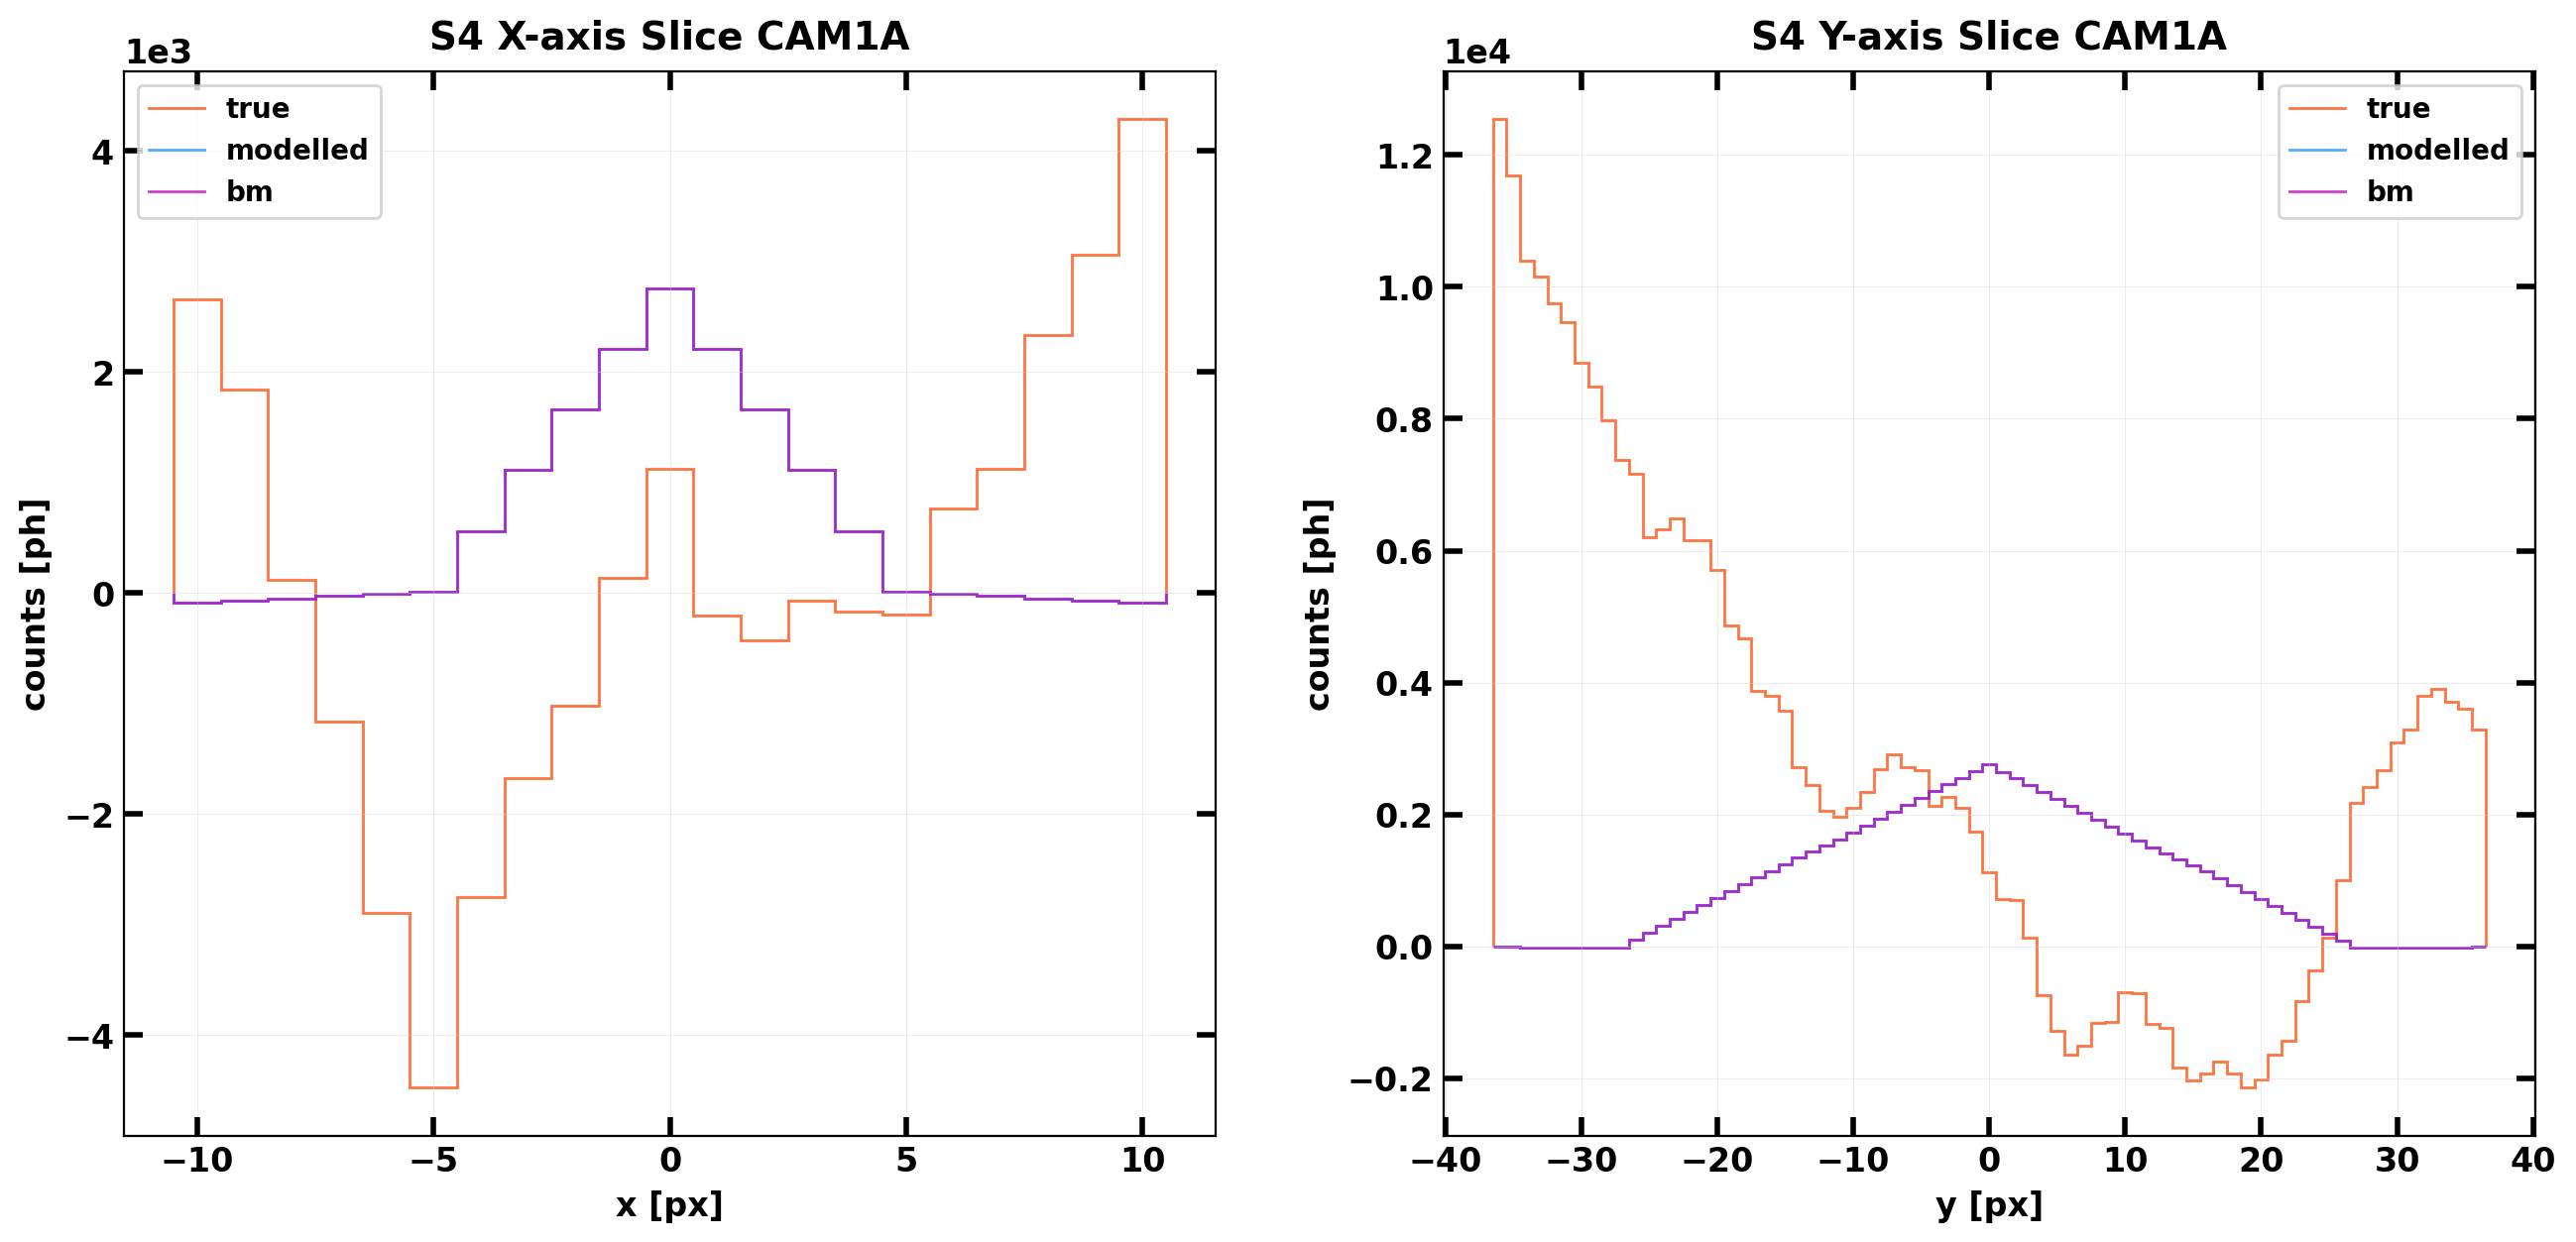

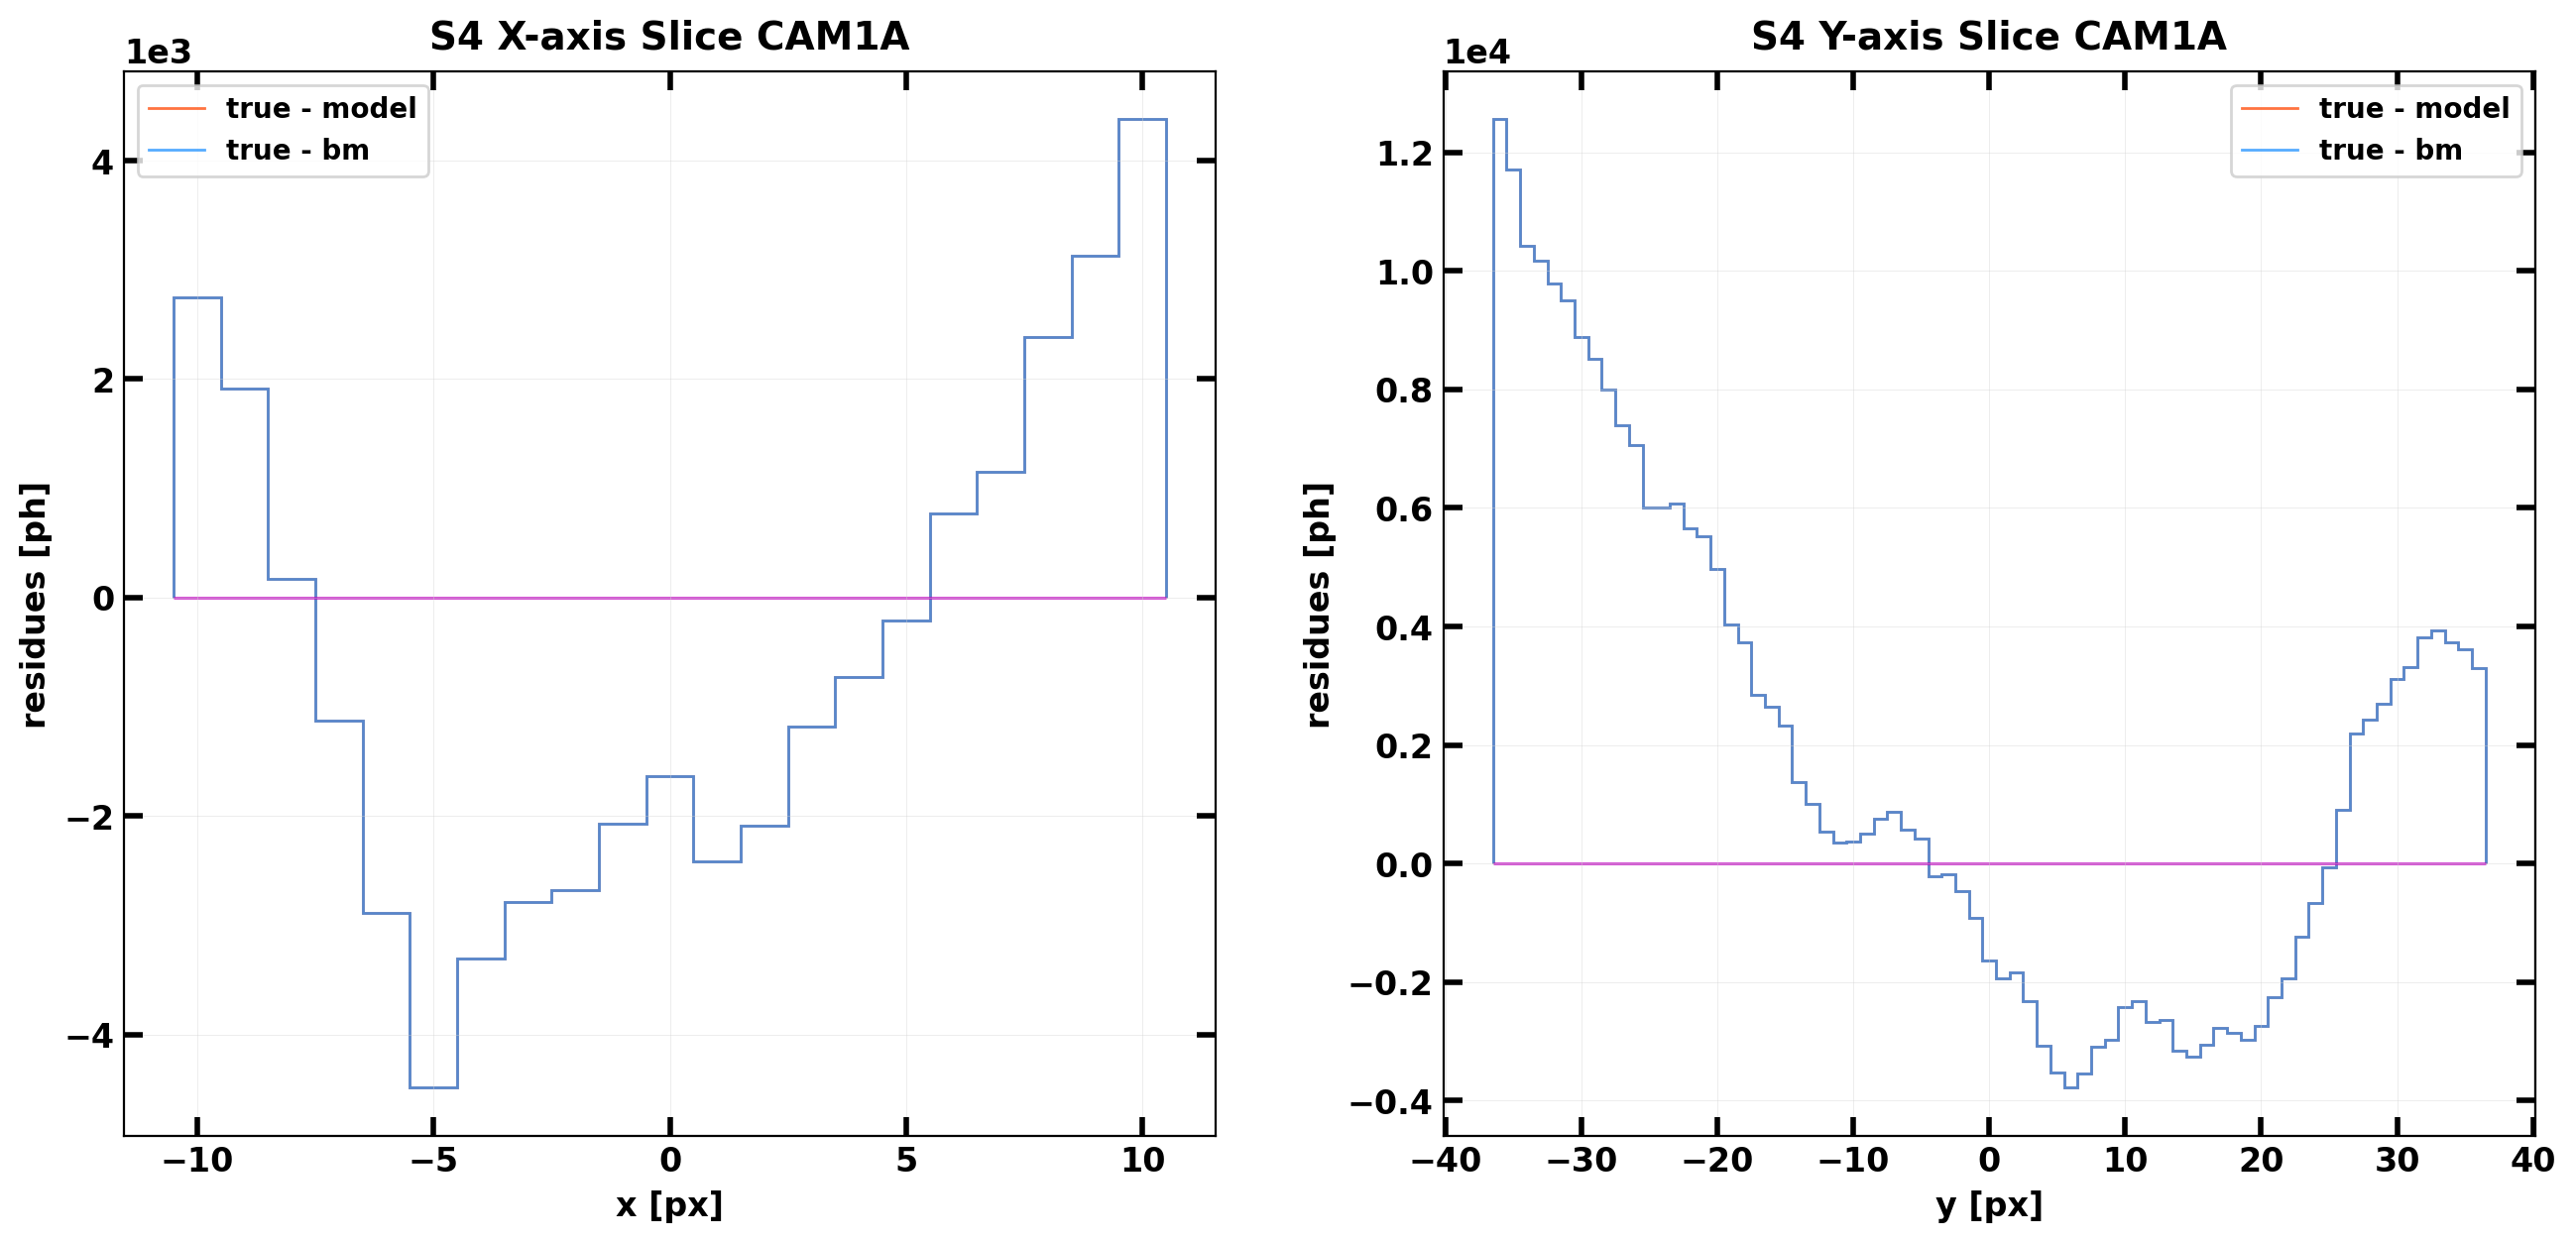

In [ ]:
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#coords = tuple(
#    CoordEquatorial(ra, dec) for ra, dec in zip(catalogueA.DLdata['RA'], catalogueA.DLdata['DEC'])
#)
#coords_ = list(coords)
#coords_.pop(idx)
sdlA = ds.get_data(
    filepaths[cam_a][dataset],
    #coords=coords_,
)

detector, _ = count(wfm, sdlA.DLdata)
true_sky = decode(wfm, detector)

sources = extract_catalogue_angular_coords(catalogueA, sdlA, wfm)
lemxSource = sources[(sources['ID'] == source_ID)]

thetax, thetay = np.array(lemxSource['THETAX'])[0], np.array(lemxSource['THETAY'])[0]
print(f'\n{source_ID.upper()} angular coords: {thetax, thetay}\n')
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.018 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6])
#fluence = np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6]) + 1.25e4

pxdimy, pxdimx = (
    wfm.specs['mask_deltay'] / wfm.upscale_f.y,
    wfm.specs['mask_deltax'] / wfm.upscale_f.x,
)

lemxSource_model = model_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
lemxSource_bm_model = bm_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_sky = true_sky - lemxSource_model

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.slices_plot(
    sky=(true_sky, lemxSource_model, lemxSource_bm_model),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    labels=('true', 'modelled', 'bm'),
    cameraID=cam_a,
    #save_to=savefig_to(save_to, f'skyslice_{source_ID}_{cam_a.upper()}' + '_newpathinmask'),
)
ds.slices_plot(
    sky=(res_sky, true_sky - lemxSource_bm_model, np.zeros(wfm.shape_sky)),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    ylabel='residues [ph]',
    labels=('true - model', 'true - bm', ''),
    cameraID=cam_a,
    #save_to=savefig_to(save_to, f'skyslice_res_{source_ID}_{cam_a.upper()}' + '_newpathinmask'),
)
#ds.slices_plot(
#    sky=lemxSource_bm_model - lemxSource_model,
#    pos=(i, j),
#    crp=crp,
#    source=f'{source_ID.upper()} model',
#    ylabel='residues [ph]',
#    labels='bm - fshift',
#    cameraID=cam_a,
#    #save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
#)

In [ ]:
from scipy.ndimage import center_of_mass
from bloodmoon.coords import pos2shift
from bloodmoon.images import argmax


def shifts_insight(
    camera: CodedMaskCamera,
    sky: NDArray,
    true_shifts: tuple[float, float],
) -> None:
    """Prints out source shifts (center of mass vs sky peak)."""
    yslit, xslit = (
        int(camera.specs['slit_deltay'] * camera.upscale_f.y / camera.specs['mask_deltay'] + 5),
        int(camera.specs['slit_deltax'] * camera.upscale_f.x / camera.specs['mask_deltax'] + 5),
    )
    labels = np.zeros(camera.shape_sky)
    labels[i - yslit : i + yslit + 1 , j - xslit : j + xslit + 1] = 1
    i_cm, j_cm = center_of_mass(sky, labels=labels, index=1)
    sx0, sy0 = camera.bins_sky.x[0], camera.bins_sky.y[0]
    ypxdim, xpxdim = (
        camera.specs['mask_deltay'] / camera.upscale_f.y,
        camera.specs['mask_deltax'] / camera.upscale_f.x,
    )
    sx_start, sy_start = sx0 + xpxdim * (j_cm - 1), sy0 + ypxdim * (i_cm - 1)
    sx_peak, sy_peak = pos2shift(camera, *argmax(sky))

    print(
        f'{source_ID.upper()} shifts: {true_shifts[0]}, {true_shifts[1]}\n'
        f'CM shifts: {sx_start}, {sy_start}\n'
        f'Peak shifts: {sx_peak}, {sy_peak}\n'
    )
    print(
        f'CM sigma (x, y): {abs(true_shifts[0] - sx_start) / xpxdim}, {abs(true_shifts[1] - sy_start) / ypxdim}\n'
        f'Peak sigma (x, y): {abs(true_shifts[0] - sx_peak) / xpxdim}, {abs(true_shifts[1] - sy_peak) / ypxdim}\n'
    )

shifts_insight(wfm, lemxSource_model, (shiftx, shifty))

SCOX1 shifts: 43.90940253074892, 78.04581352417019
CM shifts: 43.85592028087075, 76.88476070889755
Peak shifts: 43.89999999999999, 78.0

CM sigma (x, y): 2.1392899951268873, 2.3221056305452805
Peak sigma (x, y): 0.37610122995715756, 0.09162704834037072




SCOX1 angular coords: (np.float64(21.025135698738186), np.float64(-12.202274809914616))



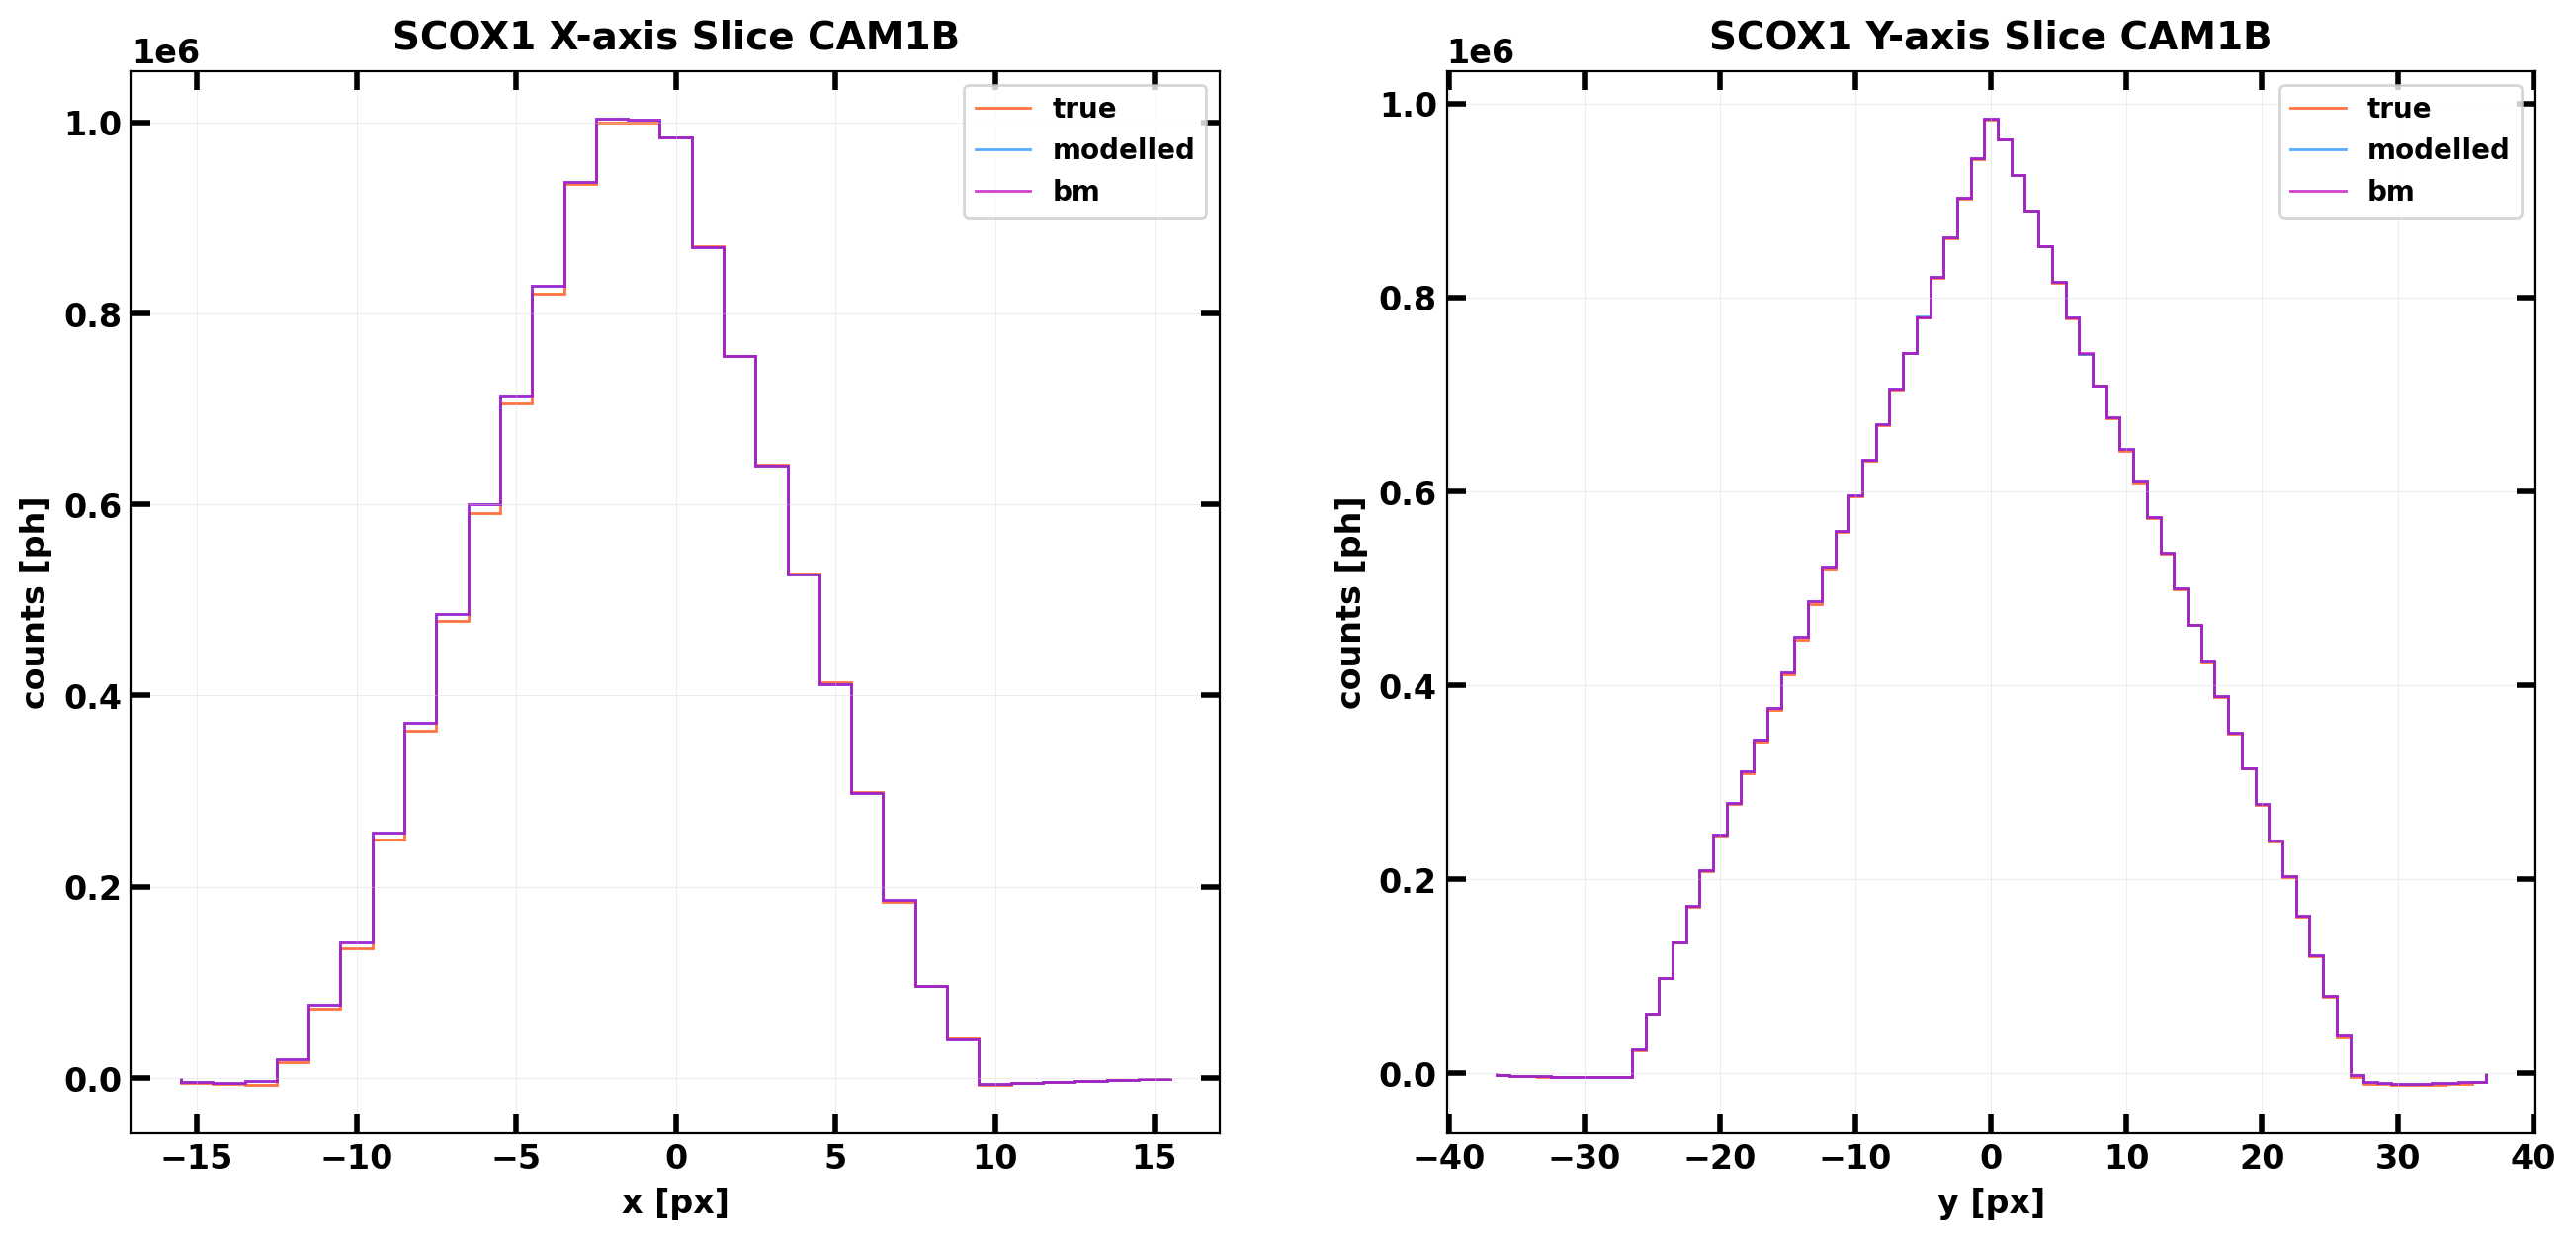

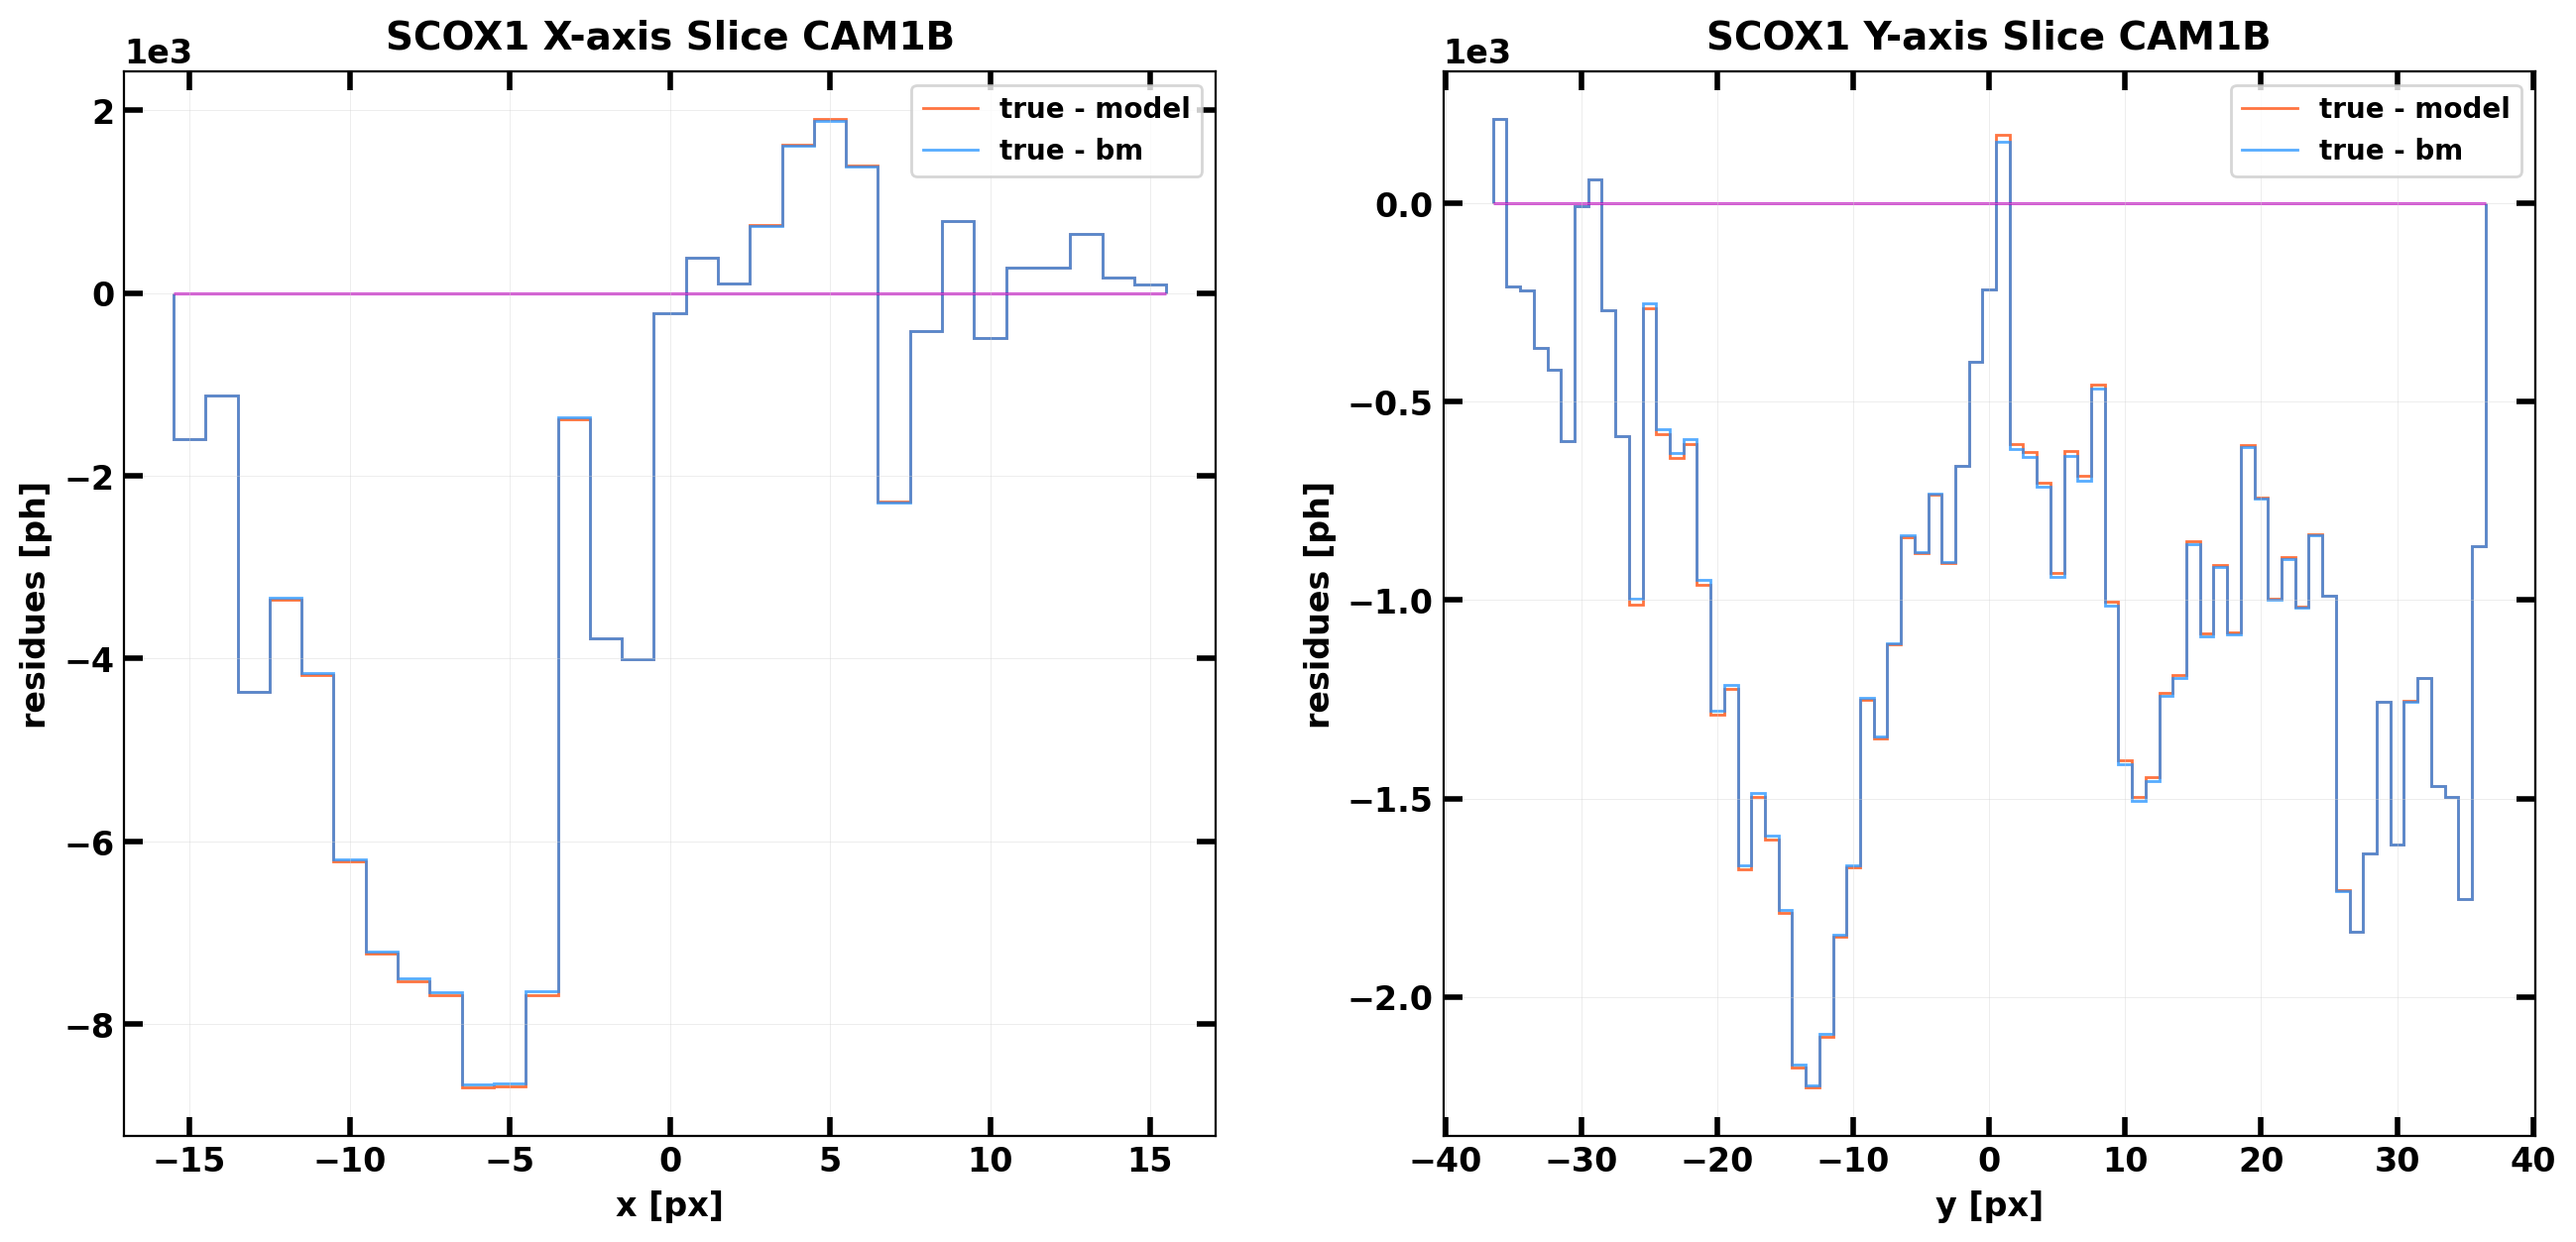

In [ ]:
catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])
#coords = tuple(
#    CoordEquatorial(ra, dec) for ra, dec in zip(catalogueB.DLdata['RA'], catalogueB.DLdata['DEC'])
#)
#coords_ = list(coords)
#coords_.pop(idx)
sdlB = ds.get_data(
    filepaths[cam_b][dataset],
    #coords=coords_,
)

detector, _ = count(wfm, sdlB.DLdata)
true_sky = decode(wfm, detector)

sources = extract_catalogue_angular_coords(catalogueB, sdlB, wfm)
lemxSource = sources[(sources['ID'] == source_ID)]

thetax, thetay = np.array(lemxSource['THETAX'])[0], np.array(lemxSource['THETAY'])[0]
print(f'\n{source_ID.upper()} angular coords: {thetax, thetay}\n')
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.009 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6]) + 2e3
#fluence = 1.0 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6]) - 1e3

pxdimy, pxdimx = (
    wfm.specs['mask_deltay'] / wfm.upscale_f.y,
    wfm.specs['mask_deltax'] / wfm.upscale_f.x,
)

alpha = 0.0
lemxSource_model = model_sky(
    camera=wfm,
    shift_x=shiftx + alpha * pxdimx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
lemxSource_bm_model = bm_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_sky = true_sky - lemxSource_model

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.slices_plot(
    sky=(true_sky, lemxSource_model, lemxSource_bm_model),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    labels=('true', 'modelled', 'bm'),
    cameraID=cam_b,
    #save_to=savefig_to(save_to, f'skyslice_{source_ID}_{cam_b.upper()}' + '_newpathinmask'),
)
ds.slices_plot(
    sky=(res_sky, true_sky - lemxSource_bm_model, np.zeros(wfm.shape_sky)),
    pos=(i, j),
    crp=crp,
    source=source_ID.upper(),
    ylabel='residues [ph]',
    labels=('true - model', 'true - bm', ''),
    cameraID=cam_b,
    #save_to=savefig_to(save_to, f'skyslice_res_{source_ID}_{cam_b.upper()}' + '_newpathinmask'),
)
#ds.slices_plot(
#    sky=lemxSource_bm_model - lemxSource_model,
#    pos=(i, j),
#    crp=crp,
#    source=f'{source_ID.upper()} model',
#    ylabel='residues [ph]',
#    labels='bm - fshift',
#    cameraID=cam_b,
#    #save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
#)

In [ ]:
shifts_insight(wfm, lemxSource_model, (shiftx, shifty))

SCOX1 shifts: 78.04581352417037, -43.909402530748885
CM shifts: 77.98069190122726, -44.5792972404484
Peak shifts: 78.0, -44.0

CM sigma (x, y): 2.6048649177243988, 1.3397894193990254
Peak sigma (x, y): 1.832540966814804, 0.18119493850223023

